# Modeling

Development of the algorithm used to forecast daily sales.

## Data Cleaning Pipeline

In [4]:
import pandas as pd

In [5]:
import sys
sys.path.append('../backend')
from preprocessing import RossmannDataTransformer

df_sales = pd.read_csv('../data/train.csv', low_memory=False)
df_store = pd.read_csv('../data/store.csv')

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
split_date = df_sales['Date'].max() - pd.Timedelta(weeks=6)

train_raw = df_sales[df_sales['Date'] <= split_date]
test_raw = df_sales[df_sales['Date'] > split_date]

# X and Y sets
X_train_raw = train_raw.copy()

X_test_raw = test_raw.copy()

> Before start training the models, we are going to create a new variable "Store means". We will tell the model the sales mean of each Store. It will be a pretty informative variable for our model!

In [6]:
# 1. Instantiate the Transformer passing the store attributes
# (Recuerda que tu clase RossmannDataTransformer internamente llama a tus funciones)
preprocessor = RossmannDataTransformer(df_attributes=df_store)

# 2. "FIT": The class cleans train and computes statistics (such as store_means)
preprocessor.fit(X_train_raw)

# 3. "TRANSFORM": Now, you apply the cleaning and the new variabls to both datasets
X_train_ready = preprocessor.transform(X_train_raw)
X_test_ready = preprocessor.transform(X_test_raw)

Important!! Now, we should filter our data because we are going to follow a 2-sted process:

* If the algorithm sees Open=0, it predicts 0 sales.
* If the algorithm sees Open=1, it uses the model.

In [7]:
mask_open_train = X_train_ready['Open'] == 1
y_train_final = X_train_ready[mask_open_train].pop('Sales')
X_train_final = X_train_ready[mask_open_train].drop(columns=['Open', 'Sales'])


mask_open_test = X_test_ready['Open'] == 1
y_test_final = X_test_ready[mask_open_test].pop('Sales')
X_test_final = X_test_ready[mask_open_test].drop(columns=['Open', 'Sales'])

## Modeling Technique Candidates
What we are going to do is:

* Phase 1: train a univariate model (Prophet) for each store.
* Compute residuals
* Phase 2: Train an XGBoost for each cluster (Performed by K-Means)

> Final Prediction: Phase 1 + Phase 2 (taking into account that if 'Open' = 0, we will predict 0 Sales)


### Evaluation Metric
**RMSPE (Root Mean Squared Percentage Error)**. It penalizes relative errors, not total ones, vital for our business.

## Phase 1 - Prophet (Cold-Tuning)

In [8]:
import numpy as np
from prophet import Prophet
from tqdm import tqdm

# 1. RMSPE Definition
def rmspe(y_true, y_pred):
    # Ensure we do not divide by 0
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask])**2))

# 2. Store predictions
train_prophet_preds = pd.Series(index=X_train_final.index, dtype=float)
test_prophet_preds = pd.Series(index=X_test_final.index, dtype=float)

stores = X_train_final['Store'].unique()

print(f"🚀 Iniciando Capa 1 (Prophet) para {len(stores)} tiendas...")

for store in tqdm(stores):
    mask_train = X_train_final['Store'] == store
    mask_test = X_test_final['Store'] == store
    
    # Prophet Format ('ds' for dates, 'y' for target)
    df_train_prophet = pd.DataFrame({
        'ds': X_train_final[mask_train].index,
        'y': y_train_final[mask_train].values
    })
    
    # 3. Train Prophet (Cold Start)
    # daily_seasonality=False because our data is aggregated by day, not hours
    m = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
    m.fit(df_train_prophet)
    
    # 4. Train Prediction
    pred_train = m.predict(df_train_prophet[['ds']])
    train_prophet_preds.loc[mask_train] = pred_train['yhat'].values
    
    # 5. Test Prediction (Validation)
    if mask_test.sum() > 0:
        df_test_prophet = pd.DataFrame({'ds': X_test_final[mask_test].index})
        pred_test = m.predict(df_test_prophet[['ds']])
        test_prophet_preds.loc[mask_test] = pred_test['yhat'].values

# 6. Evaluation of base model (Prophet)
# Cap to 0, in case Prophet predicts negative values
train_prophet_preds = np.maximum(train_prophet_preds, 0)
test_prophet_preds = np.maximum(test_prophet_preds, 0)

rmspe_train_base = rmspe(y_train_final.values, train_prophet_preds.values)
rmspe_test_base = rmspe(y_test_final.values, test_prophet_preds.values)

print("-" * 40)
print(f"📉 RMSPE Phase 1 (Train): {rmspe_train_base:.4f}")
print(f"📉 RMSPE Phase 1 (Test):  {rmspe_test_base:.4f}")
print("-" * 40)

# 7. Residuals
train_residuals = y_train_final - train_prophet_preds
test_residuals = y_test_final - test_prophet_preds
print("✅ Residuals extracted. Ready for phase 2.")

Importing plotly failed. Interactive plots will not work.


🚀 Iniciando Capa 1 (Prophet) para 1115 tiendas...


  0%|          | 0/1115 [00:00<?, ?it/s]21:21:51 - cmdstanpy - INFO - Chain [1] start processing
21:21:51 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/1115 [00:00<04:34,  4.05it/s]21:21:52 - cmdstanpy - INFO - Chain [1] start processing
21:21:52 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 2/1115 [00:00<03:38,  5.10it/s]21:21:52 - cmdstanpy - INFO - Chain [1] start processing
21:21:52 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 3/1115 [00:00<03:19,  5.57it/s]21:21:52 - cmdstanpy - INFO - Chain [1] start processing
21:21:52 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 4/1115 [00:00<03:12,  5.77it/s]21:21:52 - cmdstanpy - INFO - Chain [1] start processing
21:21:52 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 5/1115 [00:00<03:12,  5.76it/s]21:21:52 - cmdstanpy - INFO - Chain [1] start processing
21:21:52 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 6/1115 [00:01<03:12,  5.7

----------------------------------------
📉 RMSPE Phase 1 (Train): 0.2808
📉 RMSPE Phase 1 (Test):  0.2380
----------------------------------------
✅ Residuals extracted. Ready for phase 2.


## Phase 2 - XGBoost

### Cold Evaluation

In [9]:
from xgboost import XGBRegressor
# 1. Dictionary for saving our models (Vital for FastAPI)
xgb_models = {}

# Arrays to save predictions of models
train_xgb_preds = pd.Series(index=X_train_final.index, dtype=float)
test_xgb_preds = pd.Series(index=X_test_final.index, dtype=float)

# List of unique clusters (0, 1, 2, 3, 4)
clusters = sorted(X_train_final['Cluster'].unique())

print("🚀 Training Phase 2: XGBoost by Clusters...")

for c in clusters:
    print(f"   -> Training XGBoost for Cluster {c}...")
    
    # Filter data by Cluster
    mask_train_c = X_train_final['Cluster'] == c
    mask_test_c = X_test_final['Cluster'] == c
    
    X_train_c = X_train_final[mask_train_c]
    y_train_c = train_residuals[mask_train_c] # Important! The Target is the residual
    
    X_test_c = X_test_final[mask_test_c]
    
    # 2. Instantiate the model (Cold Evaluation: robust initial hyperparameters)
    xgb = XGBRegressor(
        n_estimators=200,      # Trees number
        learning_rate=0.1,     # Learning Speed
        max_depth=6,           # Depth of each tree
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    xgb.fit(X_train_c, y_train_c)
    
    # Save model in our dictionary
    xgb_models[c] = xgb
    
    # 3. Predict residuals
    train_xgb_preds.loc[mask_train_c] = xgb.predict(X_train_c)
    
    if mask_test_c.sum() > 0:
        test_xgb_preds.loc[mask_test_c] = xgb.predict(X_test_c)

print("✅ XGBoost models trained!")

# ==========================================
# 🏆 FINAL EVALUATION
# ==========================================

# Predicción Final = Capa 1 (Prophet) + Capa 2 (XGBoost)
final_train_preds = train_prophet_preds + train_xgb_preds
final_test_preds = test_prophet_preds + test_xgb_preds

# Cap negative preditions (in case)
final_train_preds = np.maximum(final_train_preds, 0)
final_test_preds = np.maximum(final_test_preds, 0)

# FINAL EVALUATION OF HYBRID SYSTEM
rmspe_train_final = rmspe(y_train_final.values, final_train_preds.values)
rmspe_test_final = rmspe(y_test_final.values, final_test_preds.values)

print("\n" + "=" * 45)
print(f"🔥 RMSPE HYBRID (Train): {rmspe_train_final:.4f}")
print(f"🔥 RMSPE HYBRID (Test):  {rmspe_test_final:.4f}")
print("=" * 45)

🚀 Training Phase 2: XGBoost by Clusters...
   -> Training XGBoost for Cluster 0...
   -> Training XGBoost for Cluster 1...
   -> Training XGBoost for Cluster 2...
   -> Training XGBoost for Cluster 3...
   -> Training XGBoost for Cluster 4...
✅ XGBoost models trained!

🔥 RMSPE HYBRID (Train): 0.1748
🔥 RMSPE HYBRID (Test):  0.2248


As we can see with these hyperparameters, the model overfits the data, overperforming in the training dataset but not on the test one. That's why we should fine tune each model in order to obtain better predictions.

### Model Validation (Fine-Tuning)

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import time

# 1. Grid of hyperparameters (The "gym" de XGBoost)
param_distributions = {
    'n_estimators': [100, 300, 500],       # Tree number
    'max_depth': [3, 5, 7],                # Depth (lower the max to avoid overfitting)
    'learning_rate': [0.01, 0.05, 0.1],    # Speed of learning
    'subsample': [0.7, 0.8, 0.9],          # % of data used by each tree (Adds randomness)
    'colsample_bytree': [0.7, 0.8, 0.9]    # % of columns that uses each tree (Avoid memorising)
}

best_xgb_models = {}
train_tuned_preds = pd.Series(index=X_train_final.index, dtype=float)
test_tuned_preds = pd.Series(index=X_test_final.index, dtype=float)

print("🚀 Initializing Fine-Tuning with RandomizedSearchCV...")
start_time = time.time()

for c in clusters:
    print(f"\n🔍 Optimizing Cluster {c}...")
    
    mask_train_c = X_train_final['Cluster'] == c
    mask_test_c = X_test_final['Cluster'] == c
    
    X_train_c = X_train_final[mask_train_c]
    y_train_c = train_residuals[mask_train_c]
    X_test_c = X_test_final[mask_test_c]
    
    # 2. Instanciate base model
    xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
    
    # 3. Configure RandomizedSearchCV (10 iterations to not waste an eternity)
    random_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_distributions,
        n_iter=10, # 10 random combinations
        scoring='neg_mean_squared_error', # Min the mean squared error
        cv=3, # CV of 3
        verbose=1,
        random_state=42,
        n_jobs=-1 
    )
    
    # 4. Train
    random_search.fit(X_train_c, y_train_c)
    
    # Extraemos el mejor modelo
    best_model = random_search.best_estimator_
    best_xgb_models[c] = best_model
    
    print(f"✅ Better Cluster parameters {c}: {random_search.best_params_}")
    
    # 5. Predict with the best model
    train_tuned_preds.loc[mask_train_c] = best_model.predict(X_train_c)
    if mask_test_c.sum() > 0:
        test_tuned_preds.loc[mask_test_c] = best_model.predict(X_test_c)

print(f"\n⏱️ Fine-Tuning completed in {(time.time() - start_time)/60:.2f} minutes.")

# ==========================================
# 🏆 EVALUATION OF FINAL MODEL
# ==========================================
final_train_preds_tuned = np.maximum(train_prophet_preds + train_tuned_preds, 0)
final_test_preds_tuned = np.maximum(test_prophet_preds + test_tuned_preds, 0)

rmspe_train_final = rmspe(y_train_final.values, final_train_preds_tuned.values)
rmspe_test_final = rmspe(y_test_final.values, final_test_preds_tuned.values)

print("\n" + "=" * 45)
print(f"🔥 RMSPE HYBRID FINE-TUNED (Train): {rmspe_train_final:.4f}")
print(f"🔥 RMSPE HYBRID FINE-TUNED (Test):  {rmspe_test_final:.4f}")
print("=" * 45)

🚀 Initializing Fine-Tuning with RandomizedSearchCV...

🔍 Optimizing Cluster 0...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Better Cluster parameters 0: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

🔍 Optimizing Cluster 1...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Better Cluster parameters 1: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

🔍 Optimizing Cluster 2...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Better Cluster parameters 2: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

🔍 Optimizing Cluster 3...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Better Cluster parameters 3: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

🔍 Optimizing Cluster 4...
Fitting 3 folds for each of

We have found a limit in our model! The model does not show improvement in the test set, indicating that with these internal data we cannot predict better the daily sales.

As we are going to focus on the AI Engineer part, we are not going to improve our model with other variables like weather or Google Trends' searchs (as the winner team of the Rossmann Kaggle competition did).

## Visualization

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random

# 1. Test data together
df_plot = X_test_final.copy()
df_plot['Actual_Sales'] = y_test_final.values
df_plot['Predicted_Sales'] = final_test_preds_tuned.values
df_plot = df_plot.reset_index()

# Colors style as "Storytelling with Data"
COLOR_REAL = '#2C7BB6'    # Blue
COLOR_PRED = '#F07E26'    # Orange
COLOR_TEXT = '#555555'    # Grey
COLOR_SPINE = '#DDDDDD'   # Clear Grey

# Apply minimalist style
def apply_minimalist_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLOR_SPINE)
    ax.spines['bottom'].set_color(COLOR_SPINE)
    ax.tick_params(bottom=False, left=False, colors=COLOR_TEXT)
    ax.yaxis.grid(True, color='#EEEEEE', linestyle='-') # Líneas guía muy sutiles
    ax.xaxis.grid(False)

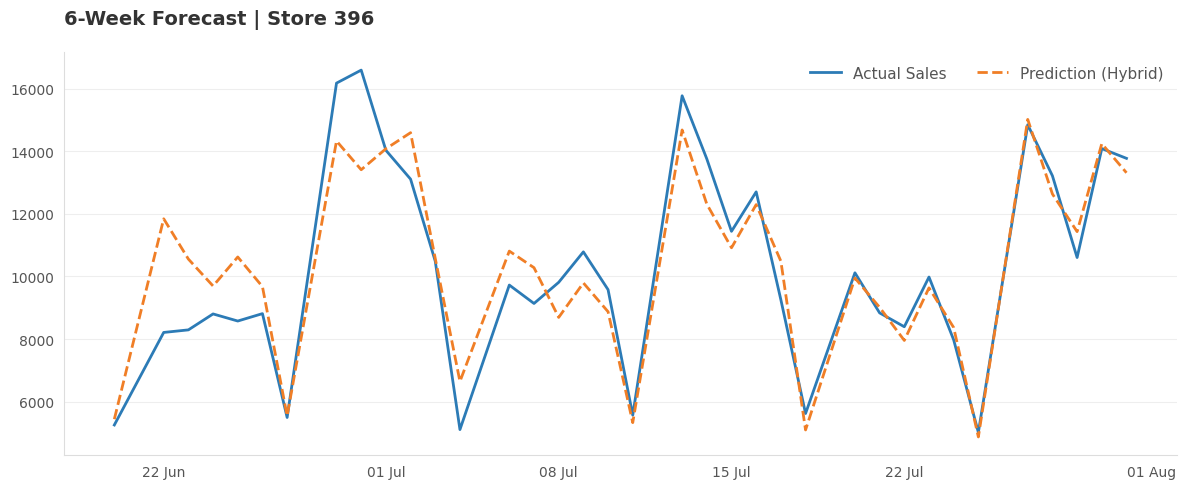

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random

# Random store
random_store = random.choice(df_plot['Store'].unique())
df_store = df_plot[df_plot['Store'] == random_store].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

# Data lines
ax.plot(df_store['Date'], df_store['Actual_Sales'], color=COLOR_REAL, linewidth=2, label='Actual Sales')
ax.plot(df_store['Date'], df_store['Predicted_Sales'], color=COLOR_PRED, linewidth=2, linestyle='--', label='Prediction (Hybrid)')

apply_minimalist_style(ax)

ax.set_title(f'6-Week Forecast | Store {random_store}', loc='left', fontsize=14, color='#333333', pad=20, fontweight='bold')

# Legend
ax.legend(frameon=False, loc='upper right', ncol=2, fontsize=11, labelcolor=COLOR_TEXT)

# Format axis X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

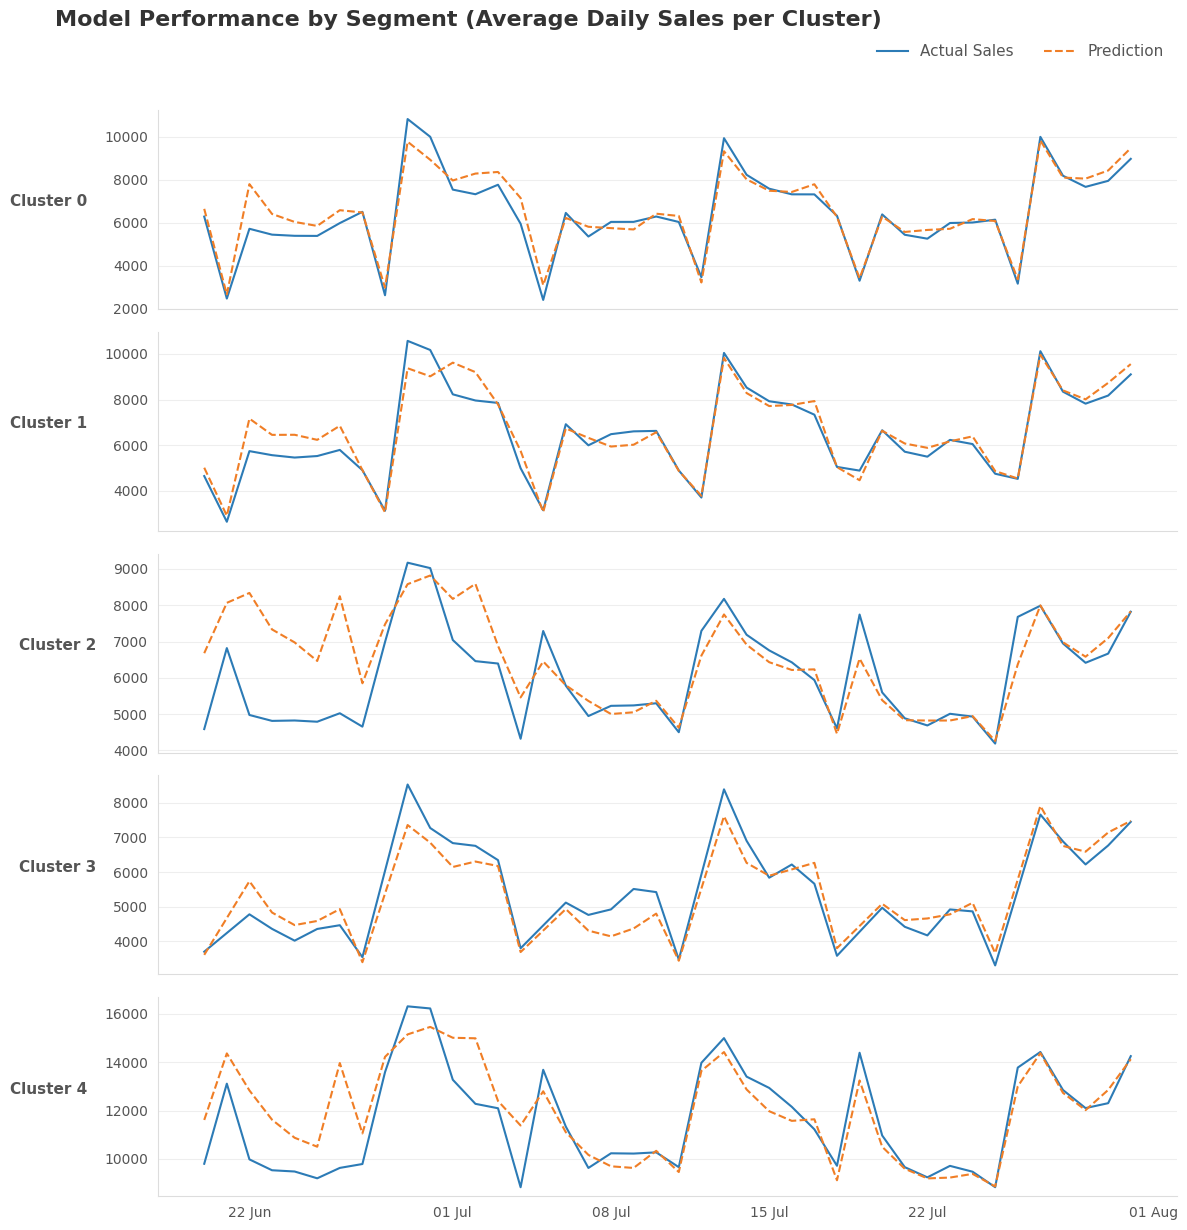

In [13]:
# Group by Date and cluster, and we compute the mean
df_cluster = df_plot.groupby(['Date', 'Cluster'])[['Actual_Sales', 'Predicted_Sales']].mean().reset_index()

clusters_list = sorted(df_plot['Cluster'].unique())
fig, axes = plt.subplots(nrows=len(clusters_list), ncols=1, figsize=(12, 2.5 * len(clusters_list)), sharex=True)

# Title
fig.suptitle('Model Performance by Segment (Average Daily Sales per Cluster)', 
             fontsize=16, color='#333333', y=0.98, fontweight='bold', x=0.05, ha='left')

for c, ax in zip(clusters_list, axes):
    df_c = df_cluster[df_cluster['Cluster'] == c].sort_values('Date')
    
    ax.plot(df_c['Date'], df_c['Actual_Sales'], color=COLOR_REAL, linewidth=1.5)
    ax.plot(df_c['Date'], df_c['Predicted_Sales'], color=COLOR_PRED, linewidth=1.5, linestyle='--')
    
    apply_minimalist_style(ax)
    
    # Cluster label
    ax.set_ylabel(f'Cluster {c}', rotation=0, labelpad=40, loc='center', color=COLOR_TEXT, fontweight='bold', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Legend
axes[0].legend(['Actual Sales', 'Prediction'], frameon=False, loc='upper right', bbox_to_anchor=(1, 1.4), ncol=2, fontsize=11, labelcolor=COLOR_TEXT)

plt.tight_layout()
fig.subplots_adjust(top=0.90) 
plt.show()

As we can see, our algorithms make really accurate predictions for the aggregate clusters (better than individual stores), indicating that the noise of each store is well managed by the aggregate predictions.

In order to improve the model for individual stores, we could:

* **Integrate External Datasets (The "Weather" Factor)**: Much of the individual store "noise" is actually driven by deterministic external events. Incorporating daily weather data (e.g., extreme temperatures, precipitation) and local macroeconomic signals (like Google Trends or regional holidays) would help the model capture sudden local drops or spikes in foot traffic.

* **Leverage Granular Geospatial Feature**s: Expanding the static store metadata (store.csv) to include exact geographic coordinates, proximity to public transit, or parking availability. This would allow the XGBoost models to better differentiate the micro-behavior of stores within the same cluster.

* **Explore Deep Learning Architectures (Future Scope)**: For the next iteration, transitioning to advanced architectures like the Temporal Fusion Transformer (TFT). TFTs are state-of-the-art for multi-horizon retail forecasting because they excel at blending static metadata (store types) with time-varying inputs (promotions, lags), learning both global retail patterns and store-specific nuances simultaneously.

## Save Model

In [14]:
import joblib
import os

MODEL_DIR = "../backend/models"

# Export our Customized Preprocessor (K-Means, clusters, average sales...)
joblib.dump(preprocessor, os.path.join(MODEL_DIR, 'rossmann_preprocessor.joblib'))
print("✅ Preprocessor saved!")

# Export the dictionary with the 5 XGBoost models (Fine-Tuned)
joblib.dump(best_xgb_models, os.path.join(MODEL_DIR, 'xgboost_clusters.joblib'))
print("✅ XGBoost models saved!")

print("\n🚀 Exported Pipeline completed. Ready for FastAPI!")

✅ Preprocessor saved!
✅ XGBoost models saved!

🚀 Exported Pipeline completed. Ready for FastAPI!
